# Session 3_Data Mining_TA: Shayan Rokhva_Professor: Dr Dehghan_

<center> <h1 style="background-color:seagreen; color:white" >Apriori Association Rules</h1>

<center><img
src="https://media-exp1.licdn.com/dms/image/C4D12AQESnIfDsWzHgw/article-cover_image-shrink_600_2000/0?e=1603929600&v=beta&t=QFUbJY8HYJi2KYoxlEur1w5M5NPaU2h-S0OBlPKA8mo" style="width:70%;height:40%;">
</center>
    
<br>    
    
<div class="list-group" id="list-tab" role="tablist">
  <h3 class="list-group-item list-group-item-action active" style="background-color:seagreen; color:white" data-toggle="list"  role="tab" aria-controls="home">Notebook Content!</h3>  
  <a class="list-group-item list-group-item-action" data-toggle="list" href="#libraries" role="tab" aria-controls="profile" style="color:forestgreen">Import Libraries<span class="badge badge-primary badge-pill" style="background-color:khaki; color:gray">1</span></a>
  <a id="section2" class="list-group-item list-group-item-action" data-toggle="list" href="#load" role="tab" aria-controls="messages" style="color:forestgreen">Load Data<span class="badge badge-primary badge-pill" style="background-color:khaki; color:gray">2</span></a>
  <a class="list-group-item list-group-item-action"  data-toggle="list" href="#tidydata" role="tab" aria-controls="settings" style="color:forestgreen">Tidy Data for Association Rules<span class="badge badge-primary badge-pill" style="background-color:khaki; color:gray">3</span></a>
  <a class="list-group-item list-group-item-action" data-toggle="list" href="#step" role="tab" aria-controls="settings" style="color:forestgreen">Step by Step<span class="badge badge-primary badge-pill" style="background-color:khaki; color:gray">4</span></a>
  <a class="list-group-item list-group-item-action" data-toggle="list" href="#myfunction" role="tab" aria-controls="settings" style="color:forestgreen">My Function<span class="badge badge-primary badge-pill" style="background-color:khaki; color:gray">5</span></a>
    <a class="list-group-item list-group-item-action" data-toggle="list" href="#ar" role="tab" aria-controls="settings" style="color:forestgreen"> Association Rules<span class="badge badge-primary badge-pill" style="background-color:khaki; color:gray">6</span></a>
    <a class="list-group-item list-group-item-action" data-toggle="list" href="#notebooks" role="tab" aria-controls="settings" style="color:forestgreen">My Notebooks<span class="badge badge-primary badge-pill" style="background-color:khaki; color:gray">7</span></a>
        <a class="list-group-item list-group-item-action" data-toggle="list" href="#ref" role="tab" aria-controls="settings" style="color:forestgreen">References<span class="badge badge-primary badge-pill" style="background-color:khaki; color:gray">8</span></a>

<a id='libraries'></a>
<h1 style="color:forestgreen" >Association Rules? What's that!</h1>

Association rule learning is a rule-based machine learning method for discovering interesting relations between variables in large databases. It is intended to identify strong rules discovered in databases using some measures of interestingness.

Based on the concept of strong rules, Rakesh Agrawal, Tomasz Imieliński and Arun Swam introduced association rules for discovering regularities between products in large-scale transaction data recorded by point-of-sale (POS) systems in supermarkets. For example, the rule {onions,potatoes} ->{burger} found in the sales data of a supermarket would indicate that if a customer buys onions and potatoes together, they are likely to also buy hamburger meat. Such information can be used as the basis for decisions about marketing activities such as, e.g., promotional pricing or product placements.

In addition to the above example from market basket analysis association rules are employed today in many application areas including Web usage mining, intrusion detection, continuous production, and bioinformatics. In contrast with sequence mining, association rule learning typically does not consider the order of items either within a transaction or across transactions. [Wikipedia]

First of all, we need to know some terms about Association Rules.

- **Support:** Support is an indication of how frequently the itemset appears in the dataset.

Support is a so-called frequency constraint. Its main feature is that it possesses the property of down-ward closure which means that all sub sets of a frequent set (support > min. support threshold) are also frequent. This property (actually, the fact that no super set of a infrequent set can be frequent) is used to prune the search space (usually a tree of item sets with increasing size) in level-wise algorithms (e.g., the APRIORI algorithm). The disadvantage of support is the rare item problem. Items that occur very infrequently in the data set are pruned although they would still produce interesting and potentially valuable rules.

- **Confidence:** Confidence is an indication of how often the rule has been found to be true.

Confidence is not down-ward closed and was developed together with support (the so-called support-confidence framework). While support is used to prune the search space and only leave potentially interesting rules, confidence is used in a second step to filter rules that exceed a min. confidence threshold. A problem with confidence is that it is sensitive to the frequency of the consequent (Y) in the data set. Caused by the way confidence is calculated, Ys with higher support will automatically produce higher confidence values even if they exists no association between the items.

- **Lift:**  The ratio of the observed support to that expected if X and Y were independent.

Leverage measures the difference of X and Y appearing together in the data set and what would be expected if X and Y where statistically dependent. The rational in a sales setting is to find out how many more units (items X and Y together) are sold than expected from the independent sells. Using min. leverage thresholds at the same time incorporates an implicit frequency constraint. E.g., for setting a min. leverage thresholds to 0.01% (corresponds to 10 occurrence in a data set with 100,000 transactions) one first can use an algorithm to find all itemsets with min. support of 0.01% and then filter the found item sets using the leverage constraint. Because of this property leverage also can suffer from the rare item problem.

- **Conviction:** The ratio of the expected frequency that X occurs without Y (that is to say, the frequency that the rule makes an incorrect prediction) if X and Y were independent divided by the observed frequency of incorrect predictions.

Conviction compares the probability that X appears without Y if they were dependent with the actual frequency of the appearance of X without Y. In that respect it is similar to lift (see section about lift on this page), however, it contrast to lift it is a directed measure. Furthermore, conviction is monotone in confidence and lift.

- **Leverage:** Leverage measures the difference of X and Y appearing together in the data set and what would be expected if X and Y where statistically dependent.

The rational in a sales setting is to find out how many more units (items X and Y together) are sold than expected from the independent sells. Using min. leverage thresholds at the same time incorporates an implicit frequency constraint. E.g., for setting a min. leverage thresholds to 0.01% (corresponds to 10 occurrence in a data set with 100,000 transactions) one first can use an algorithm to find all itemsets with min. support of 0.01% and then filter the found item sets using the leverage constraint. Because of this property leverage also can suffer from the rare item problem. [Michael Hahsler]




🔶 قوانین انجمنی چیست؟

یادگیری قوانین انجمنی یک روش داده‌کاوی مبتنی بر «قاعده» است که برای یافتن رابطه‌های جالب، تکرارشونده و معنادار میان متغیرها در مجموعه‌داده‌های بزرگ به‌کار می‌رود. هدف این روش، پیدا کردن «قواعد قوی» در میان حجم زیادی از داده‌هاست.

این روش نخستین‌بار توسط سه پژوهشگر مطرح شد که قصد داشتند الگوهای خرید مشتریان را در فروشگاه‌هایی که ثبت رایانه‌ای فروش دارند کشف کنند. برای نمونه، اگر داده‌های یک فروشگاه نشان دهد:

هر کس پیاز و سیب‌زمینی را با هم می‌خرد، معمولاً گوشت همبرگر نیز می‌خرد،

این یک قانون انجمنی است و می‌تواند برای چیدمان کالا، قیمت‌گذاری تبلیغاتی یا برنامه‌ریزی فروش استفاده شود.

امروزه این روش علاوه بر تحلیل سبد خرید، در زمینه‌هایی مانند تحلیل رفتار کاربران در وب، شناسایی نفوذهای امنیتی، فرایندهای تولیدی و حتی زیست‌اطلاعات نیز کاربرد فراوان دارد. در این روش، ترتیب رخدادها درون یک سبد یا بین سبدها اهمیتی ندارد.

🔶 مفاهیم اصلی در قوانین انجمنی
⭐ ۱) پشتیبانی

«پشتیبانی» نشان می‌دهد که یک مجموعه‌اقلام چند بار در کل مجموعه‌داده ظاهر شده است.
این معیار یک «قید بسامدی» است و ویژگی مهم آن «بسته‌شدگی نزولی» است؛ یعنی هرگاه یک مجموعه‌اقلام پرتکرار باشد، تمام زیرمجموعه‌های آن نیز پرتکرار خواهند بود.

مشکل پشتیبانی:
اقلام بسیار نادر حذف می‌شوند؛ درحالی‌که ممکن است روابط مهمی داشته باشند.

⭐ ۲) اطمینان

«اطمینان» بیان می‌کند که یک قاعده چند بار درست از آب درآمده است؛ یعنی احتمال اینکه «اگر بخش نخست رخ دهد، بخش دوم نیز رخ خواهد داد».

این معیار برخلاف پشتیبانی بسته‌شدگی نزولی ندارد و بعد از مرحله فیلتر اولیه (بر اساس پشتیبانی) برای انتخاب قواعد قوی استفاده می‌شود.

مشکل اطمینان:
اگر بخش نتیجه‌ی قاعده به‌طور طبیعی بسیار پرتکرار باشد، مقدار اطمینان به‌صورت غیرواقعی بالا می‌رود، حتی اگر رابطه‌ای واقعی وجود نداشته باشد.

⭐ ۳) بالاروی

«بالاروی» نسبتِ «رخداد واقعی هم‌زمان دو پدیده» به «رخداد مورد انتظار در صورت مستقل بودن آن‌ها» است.
این معیار نشان می‌دهد دو پدیده چقدر بیش از حالت تصادفی با هم ظاهر می‌شوند.

⭐ ۴) اهرم

«اهرم» تفاوت میان «میزان واقعیِ رخداد هم‌زمان دو پدیده» و «میزان مورد انتظار آن‌ها در حالت استقلال» را اندازه‌گیری می‌کند.
برای نمونه مشخص می‌کند چند «واحد بیشتر» دو کالا همراه هم فروخته شده‌اند نسبت به حالت فروش مستقل آن‌ها.

مشکل اهرم:
به‌دلیل نیاز به حداقل بسامد، اقلام نادر را کنار می‌گذارد.

⭐ ۵) محکمیت

«محکمیت» نسبتِ «تعداد خطاهایی که در صورت استقلال دو پدیده انتظار می‌رود اتفاق بیفتد» به «تعداد خطاهای واقعی» است.
به بیان ساده، نشان می‌دهد یک قاعده چقدر «پیش‌بینی‌پذیر» است.

این معیار شبیه بالاروی است، اما جهت‌دار است؛ یعنی تفاوت میان «از الف به ب» و «از ب به الف» را در نظر می‌گیرد.
همچنین با افزایش اطمینان و بالاروی بیشتر می‌شود.

🔶 جمع‌بندی

قوانین انجمنی ابزاری قدرتمند برای کشف الگوهای پنهان در داده‌هاست. مفاهیمی مانند پشتیبانی، اطمینان، بالاروی، اهرم و محکمیت، هرکدام جنبه‌ای از قدرت، ارزش و معنادار بودن یک قاعده را نشان می‌دهند. ترکیب این معیارها سبب می‌شود بتوان از میان تعداد بسیار زیاد ترکیب‌های ممکن، قواعد واقعاً سودمند و کاربردی را استخراج کرد.

<a id='libraries'></a>
<h1 style="color:forestgreen" >1. Packages</h1>

In [ ]:
# ----------------------------
# BASE
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

# ----------------------------
# INSTALL
# !pip install mlxtend

# ----------------------------
# TRANSACTION ENCODER
from mlxtend.preprocessing import TransactionEncoder

# ----------------------------
# APRIORI FUNCTION
from mlxtend.frequent_patterns import apriori, association_rules

# ----------------------------
# ITERTOOLS
import itertools

# ----------------------------
# CONFIGURATION
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

این بخش از کد در حقیقت قسمت پایه و مقدماتی برنامه است که برای آماده‌سازی محیط و فراهم کردن ابزارهای لازم به‌کار می‌رود. بخش نخست، بسته‌هایی را فراخوانی می‌کند که برای کار با آرایه‌ها، جدول‌های داده‌ای، ترسیم نمودارها و کارهای زمانی استفاده می‌شود. در ادامه، بسته‌ای برای آماده‌سازی داده‌های مربوط به خریدهای هم‌زمان و تبدیل فهرست کالاهای هر خریدار به ساختار مناسب برای الگوریتم قوانین انجمنی فراخوانی شده است. سپس ابزارهای مربوط به استخراج مجموعه‌های پرتکرار و قواعد انجمنی بارگذاری می‌شود. بخش بعدی برای کار با ترکیب‌های مختلف اقلام استفاده می‌شود. در پایان نیز هشدارهای مزاحم خاموش می‌شود و سامانه تنظیم می‌شود تا همه ستون‌ها نمایش داده شده و اعداد به شکل یکنواخت دیده شوند.

<a id='load'></a>
<h1 style="color:forestgreen" >2. Data</h1>

این دستور یک جدول داده‌ای را از روی پرونده‌ای که شامل فهرست خریدهای فروشگاه است بارگذاری می‌کند. با اجرای این فرمان، پرونده موردنظر خوانده شده و محتویات آن به صورت یک جدول داده‌ای در حافظه ذخیره می‌شود. در اینجا نام ستون جدول «کالاها» در نظر گرفته شده و چون پرونده سرستون ندارد، گزینه بدون سرستون فعال شده است. نتیجه این است که هر ردیف جدول، فهرست کالاهای خریداری‌شده در یک بار خرید را نمایش می‌دهد.

In [ ]:
df = pd.read_csv("../input/supermarket/GroceryStoreDataSet.csv",names=['products'],header=None)
df

,products
0,"MILK,BREAD,BISCUIT"
1,"BREAD,MILK,BISCUIT,CORNFLAKES"
2,"BREAD,TEA,BOURNVITA"
3,"JAM,MAGGI,BREAD,MILK"
4,"MAGGI,TEA,BISCUIT"
5,"BREAD,TEA,BOURNVITA"
6,"MAGGI,TEA,CORNFLAKES"
7,"MAGGI,BREAD,TEA,BISCUIT"
8,"JAM,MAGGI,BREAD,TEA"
9,"BREAD,MILK"


In [ ]:
df.shape

(20, 1)

<a id='tidydata'></a>
<h1 style="color:forestgreen" >3. Tidy Data for Association Rules</h1>

در این بخش، ستون کالاها ابتدا به صورت فهرست جداگانه برای هر خرید تبدیل می‌شود؛ یعنی کالاهای نوشته‌شده در یک ردیف از هم جدا شده و در قالب یک مجموعه برای همان خرید ذخیره می‌شود. سپس ابزار تبدیل معاملات، این مجموعه‌ها را به یک جدول عددی تبدیل می‌کند که در آن برای هر کالا یک ستون ساخته شده و مقدار «یک» نشان‌دهنده وجود آن کالا در خرید و مقدار «صفر» بیان‌کننده نبودن آن است. در پایان، جدول نهایی ساخته می‌شود. خروجی این کد یک جدول دودویی است که هر ردیف یک خرید را نشان می‌دهد و هر ستون یک کالا را. این ساختار پایه اصلی اجرای قوانین انجمنی است و امکان محاسبه تکرار کالاها و هم‌رخدادی آن‌ها را فراهم می‌کند.

In [ ]:
data = list(df["products"].apply(lambda x:x.split(',')))

from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_data = te.fit(data).transform(data)
df = pd.DataFrame(te_data,columns=te.columns_).astype(int)

df

,BISCUIT,BOURNVITA,BREAD,COCK,COFFEE,CORNFLAKES,JAM,MAGGI,MILK,SUGER,TEA
0,1,0,1,0,0,0,0,0,1,0,0
1,1,0,1,0,0,1,0,0,1,0,0
2,0,1,1,0,0,0,0,0,0,0,1
3,0,0,1,0,0,0,1,1,1,0,0
4,1,0,0,0,0,0,0,1,0,0,1
5,0,1,1,0,0,0,0,0,0,0,1
6,0,0,0,0,0,1,0,1,0,0,1
7,1,0,1,0,0,0,0,1,0,0,1
8,0,0,1,0,0,0,1,1,0,0,1
9,0,0,1,0,0,0,0,0,1,0,0


در این بخش از کد، ابتدا یک نسخه همانند از جدول ساخته می‌شود تا تغییرات بر روی آن انجام گیرد. سپس در یک حلقه، هر ستون از کالاها یکی‌یکی بررسی می‌شود. در هر بار، بررسی می‌شود که آیا آن کالا در یک خرید وجود دارد یا نه و بر اساس آن، یک ستون تازه برای نشان‌دادن حضور کالا ساخته می‌شود. سپس برای نمایش بهتر، شماره هر کالا جایگزین نام آن ستون می‌شود. پس از آن، یک نمودار نقطه‌ای رسم می‌گردد که در آن محور افقی شماره خریدها و محور عمودی کالاها هستند و رنگ نقطه‌ها نشان می‌دهد که کالا در آن خرید وجود دارد یا نه. این نمودار ساختار کلی داده‌ها را به صورت تصویری روشن می‌کند. خروجی این کد یک صفحه تصویری است که حضور و نبود هر کالا را با نقطه‌های رنگی نشان می‌دهد و درک بهتری از پراکندگی کالاها در خریدها می‌دهد.

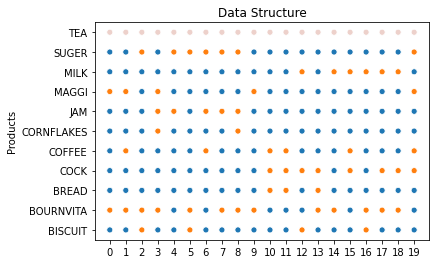

In [ ]:
p = df.copy()
for i in range(1, len(p.columns)+1):
    p["Cat"] = np.where(p[p.columns[i]] == 1, 1, 0)
    p[p.columns[i]]= i
    g =sns.scatterplot(p.index, p[p.columns[i]], hue = p.Cat, legend = False)
    g.yaxis.set_label_text('Products')
    g.set_yticks(np.arange(1, len(p.columns)))
    g.set_xticks(df.index)
    g.set_yticklabels(df.columns)
    plt.title("Data Structure")


<a id='step'></a>
<h1 style="color:forestgreen" >4. Step by Step</h1>


در این بخش از برنامه ابتدا مجموع هر ستون محاسبه می‌شود. چون ستون‌ها نمایش‌دهنده کالا هستند و مقدار «یک» در هر ردیف نشان‌دهنده حضور آن کالا در خرید است، جمع‌زدن ستون‌ها تعداد دفعات حضور هر کالا در کل خریدها را به دست می‌دهد. سپس برای به‌دست آوردن «پشتیبانی»، مقدار حضور هر کالا بر تعداد کل خریدها تقسیم می‌شود. این کار بسامد نسبی هر کالا را محاسبه می‌کند. پس از آن، این مقدارها در قالب یک جدول نو به همراه نام کالاها مرتب می‌شوند تا کالاهای پرتکرار در بالا قرار گیرند. خروجی نخستین کد تعداد حضور هر کالا را نشان می‌دهد و خروجی دوم میزان پشتیبانی هر کالا را به صورت عدد بین صفر تا یک نمایش می‌دهد؛ برای نمونه نان بیشترین حضور را دارد و برخی کالاها بسامد کم‌تری دارند.

**First Iteration:** Find support values for each product.

- n: 20 (df.shape[0])

In [ ]:
# Find Frequency of Items
df.sum()

BISCUIT        7
BOURNVITA      4
BREAD         13
COCK           3
COFFEE         8
CORNFLAKES     6
JAM            2
MAGGI          5
MILK           5
SUGER          6
TEA            7
dtype: int64

If we divide all items with row number, we can find Support value. Our threshold value is 0.2 for Support value.

In [ ]:
# Product Frequency / Total Sales
first = pd.DataFrame(df.sum() / df.shape[0], columns = ["Support"]).sort_values("Support", ascending = False)
first

,Support
BREAD,0.65
COFFEE,0.40
BISCUIT,0.35
TEA,0.35
CORNFLAKES,0.30
SUGER,0.30
MAGGI,0.25
MILK,0.25
BOURNVITA,0.20
COCK,0.15


In [ ]:
# Elimination by Support Value
first[first.Support >= 0.15]    # حد برش

,Support
BREAD,0.65
COFFEE,0.40
BISCUIT,0.35
TEA,0.35
CORNFLAKES,0.30
SUGER,0.30
MAGGI,0.25
MILK,0.25
BOURNVITA,0.20
COCK,0.15


**Second Iteration:** Find support values for pair product combinations.

در این قسمت ابتدا از میان کالاهای پرتکرار، همه جفت‌های ممکن ساخته می‌شود؛ یعنی ترکیب‌های دو‌تایی از کالاها به دست می‌آید. این کار کمک می‌کند بفهمیم کدام دو کالا معمولاً همراه با هم خریداری می‌شوند. سپس برای هر جفت کالا، تعداد خریدهایی که آن دو کالا در آن‌ها هم‌زمان وجود دارند محاسبه می‌شود. این مقدار بر تعداد کل خریدها تقسیم می‌گردد تا «پشتیبانی» هر جفت به دست آید. پس از آن یک جدول ساخته می‌شود که در آن نام هر جفت کالا، مقدار پشتیبانی آن و طول آن جفت نمایش داده می‌شود. خروجی نهایی نشان می‌دهد کدام جفت کالا بیشترین هم‌زمانی را دارند؛ برای نمونه چای و خوراکی ماگی بیشترین مقدار را داشته‌اند و برخی جفت‌ها مقدار کم‌تری دارند. همچنین مقدارهای زیر یک حد تعیین‌شده حذف شده‌اند تا فقط جفت‌های با ارزش باقی بمانند.

In [ ]:
second = list(itertools.combinations(first.index, 2))
second = [list(i) for i in second]
# Sample of combinations
second[:10]

[['BREAD', 'COFFEE'],
 ['BREAD', 'BISCUIT'],
 ['BREAD', 'TEA'],
 ['BREAD', 'CORNFLAKES'],
 ['BREAD', 'SUGER'],
 ['BREAD', 'MAGGI'],
 ['BREAD', 'MILK'],
 ['BREAD', 'BOURNVITA'],
 ['BREAD', 'COCK'],
 ['BREAD', 'JAM']]

در این بخش، برنامه برای هر جفت کالا بررسی می‌کند که آن دو کالا در چند خرید به صورت هم‌زمان دیده شده‌اند. برای این کار، جدول داده‌ای چرخانده می‌شود تا ردیف‌ها نقش کالاها را بگیرند و سپس مجموع هر جفت کالا محاسبه می‌شود. اگر خریدی شامل هر دو کالای جفت باشد، مقدار آن ردیف برابر با تعداد ستون‌های انتخاب‌شده خواهد بود. سپس تعداد این خریدها بر تعداد کل خریدها تقسیم می‌شود تا پشتیبانی جفت کالا به دست آید. مقدارهای به‌دست‌آمده در فهرستی ذخیره و به جدول تبدیل می‌شوند. در ادامه، نام هر جفت کالا و اندازه آن‌ها نیز اضافه می‌شود و جدول بر اساس بیشترین پشتیبانی مرتب می‌گردد. در پایان، جفت‌هایی که مقدار پشتیبانی‌شان کمتر از حد تعیین‌شده باشد حذف می‌شوند و تنها جفت‌های مهم باقی می‌مانند. خروجی نشان می‌دهد کدام جفت کالا بیشترین همراهی را در خریدها دارند و کدام جفت‌ها ارزش تحلیل دارند.

In [ ]:
# Finding support values
value = []
for i in range(0, len(second)):
    temp = df.T.loc[second[i]].sum()
    temp = len(temp[temp == df.T.loc[second[i]].shape[0]]) / df.shape[0]
    value.append(temp)
# Create a data frame
secondIteration = pd.DataFrame(value, columns = ["Support"])
secondIteration["index"] = [tuple(i) for i in second]
secondIteration['length'] = secondIteration['index'].apply(lambda x:len(x))
secondIteration = secondIteration.set_index("index").sort_values("Support", ascending = False)
# Elimination by Support Value
secondIteration = secondIteration[secondIteration.Support > 0.1]
secondIteration

,Support,length
index,,
"(TEA, MAGGI)",0.20,2
"(BREAD, TEA)",0.20,2
"(BREAD, SUGER)",0.20,2
"(BREAD, MILK)",0.20,2
"(BREAD, BISCUIT)",0.20,2
"(COFFEE, CORNFLAKES)",0.20,2
"(COFFEE, SUGER)",0.20,2
"(BREAD, COFFEE)",0.15,2
"(BREAD, MAGGI)",0.15,2


<a id='myfunction'></a>
<h1 style="color:forestgreen" >5. My Function</h1>

mlxtend package helps us to analyze association rules problems. In this content, I tried to create my own function for association rules.

در این قسمت، یک تابع ساخته شده که وظیفه آن اجرای مرحله‌ای روش جست‌وجوی مجموعه‌های پرتکرار است. این تابع ابتدا یک بخش درونی دارد که برای هر ترکیب از کالاها مقدار پشتیبانی را محاسبه می‌کند. در این بخش، برای هر ترکیب بررسی می‌شود که آیا همه کالاهای آن ترکیب در یک خرید با هم آمده‌اند یا نه. تعداد خریدهای شامل تمامی آن کالاها به دست می‌آید و سپس بر تعداد کل خریدها تقسیم می‌شود تا مقدار پشتیبانی محاسبه گردد. سپس این مقدارها در قالب یک جدول دسته‌بندی شده به همراه اندازه ترکیب و نام کالاها مرتب می‌شود و ترکیب‌هایی که پشتیبانی آن‌ها کمتر از حد تعیین‌شده است کنار گذاشته می‌شوند.

در مرحله نخست تابع، کالاها به صورت تک‌تک بررسی می‌شوند و پشتیبانی آن‌ها محاسبه می‌شود. کالاهایی که مقدار کافی داشته باشند نگه داشته می‌شوند و اندازه آن‌ها یک است. خروجی مرحله نخست نشان می‌دهد کدام کالاها به‌تنهایی بسامد بیشتری دارند؛ برای نمونه نان و قهوه مقدار بالاتری نسبت به بقیه داشته‌اند. مرحله دوم همین روند را برای جفت کالاها انجام می‌دهد و مشخص می‌کند کدام جفت کالا به طور هم‌زمان بیشتر دیده شده‌اند.

In [ ]:
def ar_iterations(data, num_iter = 1, support_value = 0.1, iterationIndex = None):

    # Next Iterations
    def ar_calculation(iterationIndex = iterationIndex):
        # Calculation of support value
        value = []
        for i in range(0, len(iterationIndex)):
            result = data.T.loc[iterationIndex[i]].sum()
            result = len(result[result == data.T.loc[iterationIndex[i]].shape[0]]) / data.shape[0]
            value.append(result)
        # Bind results
        result = pd.DataFrame(value, columns = ["Support"])
        result["index"] = [tuple(i) for i in iterationIndex]
        result['length'] = result['index'].apply(lambda x:len(x))
        result = result.set_index("index").sort_values("Support", ascending = False)
        # Elimination by Support Value
        result = result[result.Support > support_value]
        return result

    # First Iteration
    first = pd.DataFrame(df.T.sum(axis = 1) / df.shape[0], columns = ["Support"]).sort_values("Support", ascending = False)
    first = first[first.Support > support_value]
    first["length"] = 1

    if num_iter == 1:
        res = first.copy()

    # Second Iteration
    elif num_iter == 2:

        second = list(itertools.combinations(first.index, 2))
        second = [list(i) for i in second]
        res = ar_calculation(second)

    # All Iterations > 2
    else:
        nth = list(itertools.combinations(set(list(itertools.chain(*iterationIndex))), num_iter))
        nth = [list(i) for i in nth]
        res = ar_calculation(nth)

    return res

In [ ]:
iteration1 = ar_iterations(df, num_iter=1, support_value=0.1)
iteration1

,Support,length
BREAD,0.65,1
COFFEE,0.40,1
BISCUIT,0.35,1
TEA,0.35,1
CORNFLAKES,0.30,1
SUGER,0.30,1
MAGGI,0.25,1
MILK,0.25,1
BOURNVITA,0.20,1
COCK,0.15,1


In [ ]:
iteration2 = ar_iterations(df, num_iter=2, support_value=0.1)
iteration2

,Support,length
index,,
"(COFFEE, CORNFLAKES)",0.20,2
"(BREAD, TEA)",0.20,2
"(TEA, MAGGI)",0.20,2
"(BREAD, SUGER)",0.20,2
"(BREAD, BISCUIT)",0.20,2
"(BREAD, MILK)",0.20,2
"(COFFEE, SUGER)",0.20,2
"(BREAD, COFFEE)",0.15,2
"(COFFEE, COCK)",0.15,2


In [ ]:
iteration3 = ar_iterations(df, num_iter=3, support_value=0.01,
              iterationIndex=iteration2.index)
iteration3

,Support,length
index,,
"(SUGER, BREAD, COFFEE)",0.10,3
"(BISCUIT, TEA, MAGGI)",0.10,3
"(BREAD, BISCUIT, MILK)",0.10,3
"(BREAD, TEA, MAGGI)",0.10,3
"(CORNFLAKES, BISCUIT, COFFEE)",0.10,3
"(COCK, CORNFLAKES, COFFEE)",0.10,3
"(COCK, CORNFLAKES, BISCUIT)",0.10,3
"(BOURNVITA, BREAD, TEA)",0.10,3
"(COCK, BISCUIT, COFFEE)",0.10,3


In [ ]:
iteration4 = ar_iterations(df, num_iter=4, support_value=0.01,
              iterationIndex=iteration3.index)
iteration4

,Support,length
index,,
"(COFFEE, COCK, CORNFLAKES, BISCUIT)",0.10,4
"(BISCUIT, TEA, BREAD, MAGGI)",0.05,4
"(COFFEE, CORNFLAKES, TEA, MILK)",0.05,4
"(CORNFLAKES, BISCUIT, MILK, BREAD)",0.05,4


<a id='ar'></a>
<h1 style="color:forestgreen" >6. Association Rules</h1>

There are two main functions here.
- apriori() function evaluate support value for each product.
- association_rules() function help us to understand relationship between antecedents and consequences products. It gives some remarkable information about products.

Especially, "antecedent support", "consequent support", "support", "confidence" and	"lift" variables are very important to make some business decisions.

🔶 توضیح کامل و علمی درباره اجرای روش آپریوری (حدود سیصد واژه)

در این بخش از برنامه، یکی از شناخته‌شده‌ترین روش‌های کشف الگوهای تکرارشونده در داده‌های خرید، یعنی «روش آپریوری»، اجرا می‌شود. پیش از این مرحله، داده‌ها به شکل جدول دودویی آماده شده بودند؛ به این معنا که برای هر کالا یک ستون و برای هر خرید یک ردیف وجود دارد و مقدار «یک» نشان‌دهنده حضور کالا در خرید است. اکنون با استفاده از دستور مربوط به روش آپریوری، مجموعه کالاهایی که با بسامد کافی در میان خریدها ظاهر می‌شوند محاسبه می‌گردند.

روش آپریوری بر پایه یک اصل مهم بنا شده است: اگر یک مجموعه از کالاها پرتکرار باشد، تمام زیرمجموعه‌های آن نیز باید پرتکرار باشند. بنابراین ابتدا کالاها به صورت تک‌تک بررسی می‌شوند و بسامد هر کدام محاسبه می‌شود. هر کالایی که مقدار پشتیبانی آن کمتر از حد تعیین‌شده باشد کنار گذاشته می‌شود؛ زیرا نمی‌تواند بخشی از یک مجموعه پرتکرار بزرگ‌تر باشد.

در مرحله بعد، کالاهای باقی‌مانده به صورت جفت ترکیب می‌شوند و پشتیبانی جفت‌ها محاسبه می‌شود. جفت‌هایی که مقدار کافی ندارند کنار گذاشته می‌شوند. سپس از جفت‌های باقی‌مانده، مجموعه‌های سه‌تایی تشکیل می‌شود و دوباره بسامد هر ترکیب بررسی می‌شود. این روند همین‌طور ادامه می‌یابد تا هیچ ترکیب تازه و معناداری که بسامد کافی داشته باشد باقی نماند.

کدی که در اینجا اجرا شده این مراحل را به‌صورت خودکار انجام می‌دهد. مقدار حد تعیین‌شده برای پشتیبانی برابر یک‌دهم است؛ یعنی یک مجموعه کالا باید دست‌کم در یک‌دهم خریدها وجود داشته باشد تا در نتیجه پایانی باقی بماند. پس از اجرای روش، برنامه تعداد ترکیب‌ها را بررسی کرده و مجموعه‌های پرتکرار را همراه با مقدار پشتیبانی آن‌ها نمایش می‌دهد. نتیجه نشان می‌دهد که برخی کالاها مانند نان، قهوه و بیسکویت از بسامد بالایی برخوردارند و حتی بعضی جفت‌ها نیز همراهی نسبتاً بالایی دارند. این نتایج پایه اصلی کشف الگوهای خرید و استخراج روابط میان کالاهاست و می‌تواند پیش‌نیاز مرحله استخراج قواعد باشد.

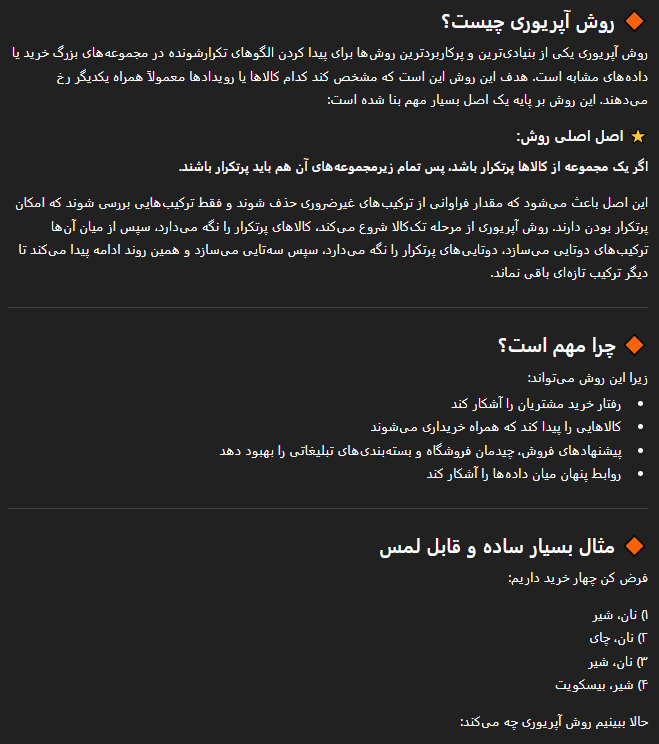

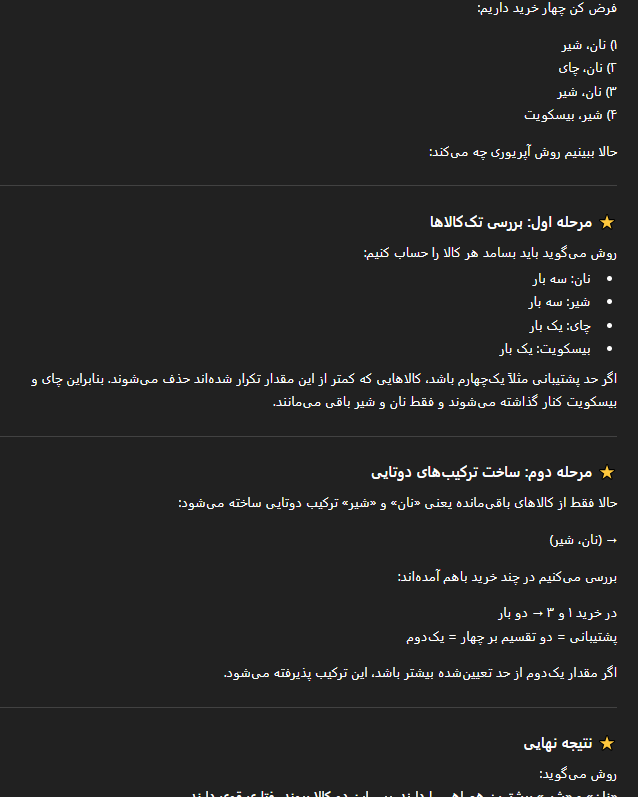

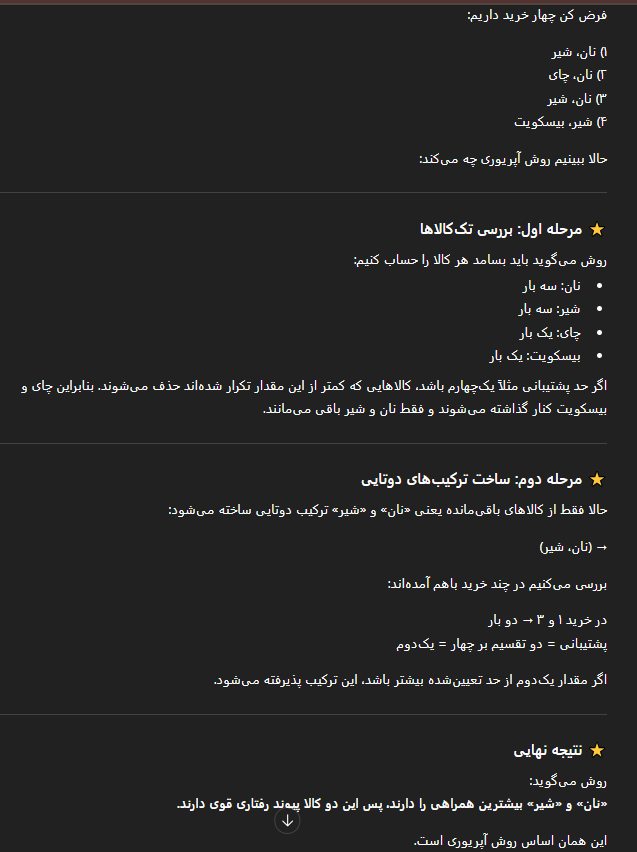

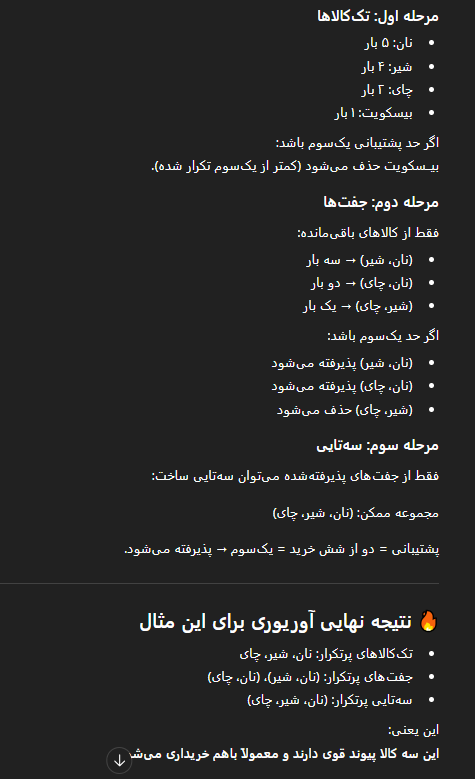

در این بخش، برنامه روش «آپریوری» را بر روی جدول دودویی کالاها اجرا می‌کند تا مجموعه‌هایی از کالاها که به اندازه کافی در خریدها تکرار شده‌اند پیدا شوند. در خط نخست، دستور مربوط به روش آپریوری فراخوانی می‌شود. در این دستور مقدار حد پشتیبانی برابر یک‌دهم قرار داده شده؛ یعنی هر مجموعه کالا باید دست‌کم در یک‌دهم از خریدها ظاهر شده باشد تا پذیرفته شود. گزینه استفاده از نام ستون‌ها فعال شده تا به‌جای شماره‌ها، نام واقعی کالاها در نتیجه نمایش داده شود. همچنین گزارش روند پردازش چاپ می‌شود تا مشخص باشد روش چند ترکیب را بررسی کرده است. پس از پایان کار، جدول حاصل شامل همه مجموعه‌های پرتکرار همراه با مقدار پشتیبانی آن‌ها است. در خط دوم، این جدول بر اساس مقدار پشتیبانی از بیشترین به کمترین مرتب می‌شود تا مشخص گردد کدام کالاها یا ترکیب‌ها بیشترین حضور را در خریدها داشته‌اند.

In [ ]:
# Apriori
freq_items = apriori(df, min_support = 0.1, use_colnames = True, verbose = 1)
freq_items.sort_values("support", ascending = False)

Processing 108 combinations | Sampling itemset size 4


,support,itemsets
2,0.65,(BREAD)
4,0.40,(COFFEE)
0,0.35,(BISCUIT)
10,0.35,(TEA)
5,0.30,(CORNFLAKES)
9,0.30,(SUGER)
7,0.25,(MAGGI)
8,0.25,(MILK)
30,0.20,"(SUGER, COFFEE)"
34,0.20,"(MAGGI, TEA)"


### Support value gives us these information:

**Head 5**
- 65 percent of 100 purchases are "BREAD"
- 40 percent of 100 purchases are "COFFEE"
- 35 percent of 100 purchases are "BISCUIT"
- 35 percent of 100 purchases are "TEA"
- 30 percent of 100 purchases are "CORNFLAKES"

**Tail 5**
- 10 percent of 100 purchases are "MAGGI" and "BISCUIT"
- 10 percent of 100 purchases are "MILK" and "BISCUIT"
- 10 percent of 100 purchases are "TEA" and "BISCUIT"
- 10 percent of 100 purchases are "JAM" and "BISCUIT"
- 10 percent of 100 purchases are "COCK", "COFFEE", "BISCUIT" and "CORNFLAKES"

In [ ]:
freq_items.sort_values("support", ascending = False).head(5)

,support,itemsets
2,0.65,(BREAD)
4,0.40,(COFFEE)
0,0.35,(BISCUIT)
10,0.35,(TEA)
5,0.30,(CORNFLAKES)


In [ ]:
freq_items.sort_values("support", ascending = False).tail(5)

,support,itemsets
15,0.10,"(BISCUIT, MAGGI)"
16,0.10,"(BISCUIT, MILK)"
17,0.10,"(BISCUIT, TEA)"
22,0.10,"(BREAD, JAM)"
45,0.10,"(COFFEE, BISCUIT, COCK, CORNFLAKES)"


این دستور از روی مجموعه‌های پرتکرار، «قواعد انجمنی» استخراج می‌کند؛ یعنی روابطی از نوع «اگر این کالاها خریده شوند، احتمال خرید چه کالاهای دیگری وجود دارد؟». در اینجا معیار اصلی ارزیابی، «اطمینان» است و تنها قواعدی نگه داشته می‌شوند که مقدار اطمینان آن‌ها دست‌کم برابر نصف باشد. برنامه برای هر قاعده چند مقدار مهم محاسبه می‌کند؛ مانند پشتیبانی پیش‌نیاز، پشتیبانی نتیجه، اطمینان، بالاروی، اهرم و محکمیّت. این جدول نشان می‌دهد کدام کالاها معمولاً همراه هم خریداری می‌شوند و قدرت و ارزش پیش‌بینی هر رابطه چقدر است.

خروجی جدول شامل چند ده قاعده است؛ برای نمونه در یکی از سطرها آمده است: «اگر بیسکویت خریداری شود، احتمال خرید نان نیز بالا است». این سطر نشان می‌دهد که بسامد هم‌زمانی این دو کالا نسبت به داده‌های کلی بیشتر است و مقدار اطمینان آن بالاتر از حد تعیین‌شده است. این یعنی خریدارانی که بیسکویت می‌خرند، در بسیاری از موارد نان نیز تهیه کرده‌اند و این رابطه می‌تواند در چیدمان فروشگاه، پیشنهاد فروش یا تحلیل رفتار خریداران کاربرد داشته باشد.

In [ ]:
# Association Rules & Info
df_ar = association_rules(freq_items, metric = "confidence", min_threshold = 0.5)
df_ar

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(BISCUIT),(BREAD),0.35,0.65,0.20,0.57,0.88,-0.03,0.82
1,(COCK),(BISCUIT),0.15,0.35,0.10,0.67,1.90,0.05,1.95
2,(CORNFLAKES),(BISCUIT),0.30,0.35,0.15,0.50,1.43,0.04,1.30
3,(BOURNVITA),(BREAD),0.20,0.65,0.15,0.75,1.15,0.02,1.40
4,(BOURNVITA),(SUGER),0.20,0.30,0.10,0.50,1.67,0.04,1.40
...,...,...,...,...,...,...,...,...,...
61,"(COFFEE, CORNFLAKES)","(BISCUIT, COCK)",0.20,0.10,0.10,0.50,5.00,0.08,1.80
62,"(BISCUIT, COCK)","(COFFEE, CORNFLAKES)",0.10,0.20,0.10,1.00,5.00,0.08,inf
63,"(BISCUIT, CORNFLAKES)","(COFFEE, COCK)",0.15,0.15,0.10,0.67,4.44,0.08,2.55
64,"(COCK, CORNFLAKES)","(COFFEE, BISCUIT)",0.10,0.10,0.10,1.00,10.00,0.09,inf


- Antecedent support variable tells us probability of antecedent products alone
- Consequents support variable tells us probability of consequents products alone
- The support value is the value of the two products (Antecedents and Consequents)
- Confidence is an indication of how often the rule has been found to be true.
- The ratio of the observed support to that expected if X and Y were independent.

این بخش از برنامه جدول قواعد انجمنی را فیلتر می‌کند تا فقط قواعدی باقی بمانند که هم مقدار پشتیبانی آن‌ها بیش از مقدار تعیین‌شده باشد و هم مقدار اطمینان آن‌ها از نصف بیشتر باشد. این کار کمک می‌کند تنها روابطی دیده شوند که هم بسامد کافی در خریدها داشته‌اند و هم قدرت پیش‌بینی بالایی دارند. سپس قواعد بر اساس مقدار اطمینان به صورت نزولی مرتب می‌شوند تا قوی‌ترین و قابل‌اعتمادترین روابط در بالای جدول قرار گیرند. خروجی نشان می‌دهد که برای نمونه، هنگامی که «شیر» خریداری شود، احتمال خرید «نان» زیاد است یا هنگامی که «خوراکی ماگی» تهیه شود، احتمال خرید «چای» بیش از حد پذیرفته‌شده است. این نتایج روابط واقعی و باارزش میان کالاها را نشان می‌دهد و می‌تواند در تحلیل رفتار خریداران، چیدمان فروشگاه و پیشنهادهای فروش کمک‌کننده باشد.

In [ ]:
df_ar[(df_ar.support > 0.15) & (df_ar.confidence > 0.5)].sort_values("confidence", ascending = False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
8,(MILK),(BREAD),0.25,0.65,0.20,0.80,1.23,0.04,1.75
18,(MAGGI),(TEA),0.25,0.35,0.20,0.80,2.29,0.11,3.25
9,(SUGER),(BREAD),0.30,0.65,0.20,0.67,1.03,0.01,1.05
14,(CORNFLAKES),(COFFEE),0.30,0.40,0.20,0.67,1.67,0.08,1.80
15,(SUGER),(COFFEE),0.30,0.40,0.20,0.67,1.67,0.08,1.80
0,(BISCUIT),(BREAD),0.35,0.65,0.20,0.57,0.88,-0.03,0.82
10,(TEA),(BREAD),0.35,0.65,0.20,0.57,0.88,-0.03,0.82
19,(TEA),(MAGGI),0.35,0.25,0.20,0.57,2.29,0.11,1.75


<h3 style="color:forestgreen" >If you like the notebook, don’t forget upvote! :)</h3>

<a id='ref'></a>
<h1 style="color:forestgreen" >8. References</h1>


- https://www.kaggle.com/mariekaram/apriori-association-rule
- https://www.kdnuggets.com/2016/04/association-rules-apriori-algorithm-tutorial.html
- https://towardsdatascience.com/association-rules-2-aa9a77241654
- https://michael.hahsler.net/research/recommender/associationrules.html
- https://en.wikipedia.org/wiki/Association_rule_learning#:~:text=Association%20rules%20are%20usually%20required,frequent%20itemsets%20in%20a%20database.

<center><img
src="https://lh3.googleusercontent.com/proxy/Cb3QDxNobx1fBiPevV54WqsodXpXyrNuUQ1J00viqe5-ep2pgTUy-TVlYinwcTmdG_Wu5bcxxZY1q8XxVNtL6COkUP8UtcswpbepNoYt8TCqMfaa3SBV_w8UG5ZSx9KMMMEMTwHO_hXs30FsbvqbevAK_HM" style="width:40%;height:40%;">
</center>